# Viral Content Predictor
**By: Dhrithi Venkatesh & Shreya Bhatlapenumarti**

Predicts whether a social media post will go viral using engagement metrics across Instagram, TikTok, and YouTube.

**Dataset:** [Viral Social Media Trends & Engagement Analysis – Kaggle](https://www.kaggle.com/datasets/atharvasoundankar/viral-social-media-trends-and-engagement-analysis)

---
### Pipeline Overview
1. Install & Import Libraries
2. Load Dataset
3. Data Cleaning & Preprocessing
4. Feature Engineering
5. Database Storage (PostgreSQL / SQLite)
6. Exploratory Data Analysis (EDA)
7. Platform-Specific Model Training
8. Model Evaluation & Comparison
9. Feature Importance & ROC Curves
10. Interactive Viral Predictor

## 1. Install & Import Libraries

In [1]:

# !pip install pandas numpy scikit-learn xgboost matplotlib seaborn

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import xgboost as xgb #


# these are basic plot settings to make the graphs look cleaner
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

PLATFORM_COLORS = {'Instagram': '#E1306C', 'TikTok': '#2EC4B6', 'YouTube': '#FF0000'}  # defined once, reused throughout
#relevant platforms for the project 
PLATFORMS       = ['Instagram','TikTok','YouTube']
RANDOM_STATE    = 42        #for consistency when splitting data 
VIRAL_PERCENTILE = 75       # this is the top 25% by Engagement_Score per platform --> Viral

print('Libraries loaded.')

Libraries loaded.


## 2. Load Dataset

In [2]:
file_path = "Cleaned_Viral_Social_Media_Trends.csv"

if not os.path.exists(file_path):
    print("file not found, download it from kaggle")
else:
    df_raw = pd.read_csv(file_path, parse_dates=["Post_Date"])
    print("loaded data")
    print("rows, cols:", df_raw.shape)
    print("\ncolumns:")
    print(df_raw.columns.tolist())
    df_raw.head()

loaded data
rows, cols: (5000, 11)

columns:
['Post_ID', 'Post_Date', 'Platform', 'Hashtag', 'Content_Type', 'Region', 'Views', 'Likes', 'Shares', 'Comments', 'Engagement_Level']


## 3. Data Cleaning & Preprocessing

In [3]:
# clean the data

metrics = ["Views", "Likes", "Shares", "Comments"]
df = df_raw.copy()
df.columns = df.columns.str.strip()

# step 1: dorp the rows that have all the missing engagement numbers
before = len(df)
df = df.dropna(subset=metrics)
print("step 1 - missing rows removed:", before - len(df))
# step 2: remove all the duplicate rows
before = len(df)
df = df.drop_duplicates()
print("step 2 - duplicates removed:", before - len(df))

# step 3: fix the platform names
df["Platform"] = df["Platform"].str.strip().str.title()
df["Platform"] = df["Platform"].replace({
 "Tiktok": "TikTok",
 "Youtube": "YouTube"
})
# step 4:just keep the platforms in our project
before = len(df)
df = df[df["Platform"].isin(PLATFORMS)].copy()
print("step 3/4- rows after platform filter:", len(df))
print("step 3/4- rows removed:", before - len(df))
# step 5: make the engagement columns numeric
df[metrics] = df[metrics].astype(float)
# step 6:remove any negative values
before = len(df)
df = df[(df[metrics] >= 0).all(axis=1)]
print("step 5/6 - negative rows removed:", before - len(df))

# step 7:cap all the extreme values at the 99th percentile for each platform
for p in PLATFORMS:
    rows = df["Platform"] == p
    for col in metrics:
        cap = df.loc[rows, col].quantile(0.99)
        df.loc[rows & (df[col] > cap), col] = cap
print("step 7- outliers capped")

# step 8: convert metrics back to whole numbers
df[metrics] = df[metrics].round().astype(int)
print("step 8 - metric columns converted back to integers")
# step 9:removing all the old label so the model does not cheat
if "Engagement_Level" in df.columns:
    df = df.drop(columns=["Engagement_Level"])
    print("step 9 - removed Engagement_Level")

print("\nfinal shape:", df.shape)
print("\nposts by platform:")
print(df["Platform"].value_counts())
df.describe()

step 1 - missing rows removed: 0
step 2 - duplicates removed: 0
step 3/4- rows after platform filter: 3796
step 3/4- rows removed: 1204
step 5/6 - negative rows removed: 0
step 7- outliers capped
step 8 - metric columns converted back to integers
step 9 - removed Engagement_Level

final shape: (3796, 10)

posts by platform:
Platform
YouTube      1324
TikTok       1260
Instagram    1212
Name: count, dtype: int64


,Post_Date,Views,Likes,Shares,Comments
count,3796,3.796000e+03,3796.000000,3796.00000,3796.000000
mean,2022-12-31 02:51:05.121180416,2.489961e+06,253225.218915,50606.14726,25021.817439
min,2022-01-01 00:00:00,1.266000e+03,490.000000,52.00000,18.000000
25%,2022-07-01 00:00:00,1.175712e+06,128004.750000,25083.00000,12419.000000
50%,2022-12-26 00:00:00,2.500447e+06,253435.000000,50972.00000,25230.500000
75%,2023-06-30 06:00:00,3.759205e+06,375860.500000,75728.00000,37182.000000
max,2023-12-30 00:00:00,4.971783e+06,496819.000000,99015.00000,49407.000000
std,NaN,1.457748e+06,144491.881653,29058.19342,14225.217528


In [4]:
# null check and platform distribution
print('Null counts:')
print(df[metrics].isnull().sum().to_string())
print('\nPost count by platform:')
print(df['Platform'].value_counts().to_string())

Null counts:
Views       0
Likes       0
Shares      0
Comments    0

Post count by platform:
Platform
YouTube      1324
TikTok       1260
Instagram    1212


## 4. Feature Engineering

In [5]:
# create the engagement columns
df['Engagement_Score'] = df['Likes'] + df['Comments'] + df['Shares']
df['Engagement_Rate']  = df['Engagement_Score'] / (df['Views'] + 1)


df['Like_to_View']     = df['Likes']    / (df['Views'] + 1)
df['Share_to_View']    = df['Shares']   / (df['Views'] + 1)
df['Comment_to_View']  = df['Comments'] / (df['Views'] + 1)
df['Share_to_Like'] = df['Shares'] / (df['Likes'] + 1)

# get the date-realted columns
df['Month']      = df['Post_Date'].dt.month
df['DayOfWeek']  = df['Post_Date'].dt.dayofweek   # 0 is Mon and 6 = Sunday
df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)

# turning text columns into numbers for the model to easily understand 
le_content = LabelEncoder()
le_region  = LabelEncoder()
le_hashtag = LabelEncoder()
df['Content_Type_Enc'] = le_content.fit_transform(df['Content_Type'].fillna('Unknown'))
df['Region_Enc']       = le_region.fit_transform(df['Region'].fillna('Unknown'))
df['Hashtag_Enc']      = le_hashtag.fit_transform(df['Hashtag'].fillna('Unknown'))
print('content types:', df['Content_Type'].unique().tolist())
print('Region values:', df['Region'].unique().tolist())

# Viral label: top 25% Engagement_Score PER PLATFORM --> considered as Viral
# platform specific thresholds are used since virality is different per platform
df['Viral'] = 0
for p in PLATFORMS:
    rows      = df['Platform'] == p
    cutoff = df.loc[rows, 'Engagement_Score'].quantile(VIRAL_PERCENTILE / 100)
    df.loc[rows & (df['Engagement_Score'] >= cutoff), 'Viral'] = 1

    viral_count = df.loc[rows, "Viral"].sum()
    total_count = rows.sum()
    print(p, "cutoff:", round(cutoff), "viral:", int(viral_count), "out of", int(total_count))

print("viral column created")
print("number of columns now:", len(df.columns))

content types: ['Video', 'Shorts', 'Post', 'Tweet', 'Live Stream', 'Reel']
Region values: ['UK', 'India', 'Australia', 'Brazil', 'Japan', 'Germany', 'Canada', 'USA']
Instagram cutoff: 461652 viral: 303 out of 1212
TikTok cutoff: 440542 viral: 315 out of 1260
YouTube cutoff: 458291 viral: 331 out of 1324
viral column created
number of columns now: 23


## 5. Exploratory Data Analysis (EDA)

In [ ]:
# Engagement distributions by platform

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle("Engagement Distributions by Platform", fontsize=14, fontweight='bold')

for ax, m in zip(axes.flatten(), metrics):
    sns.boxplot(
        data=df, x="Platform", y=m, ax=ax,
        palette=PLATFORM_COLORS, showfliers=False, linewidth=1.2
    )
    ax.set_title(m, fontweight='bold')
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()


#### 6.2 Engagement Rate Distribution (Viral vs Non-Viral)

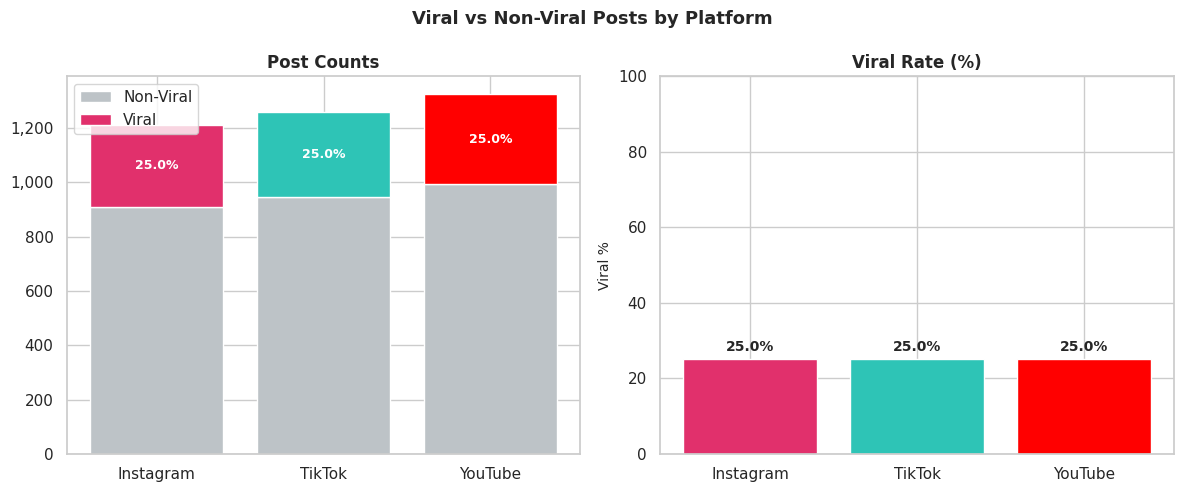

In [7]:
# Viral vs Non-Viral breakdown per platform

summary = df.groupby("Platform")["Viral"].agg(["sum", "count"]).reset_index()
summary.columns = ["Platform", "viral_count", "total"]
summary["nonviral"]  = summary["total"] - summary["viral_count"]
summary["viral_pct"] = summary["viral_count"] / summary["total"] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Viral vs Non-Viral Posts by Platform", fontsize=13, fontweight='bold')

x = range(len(summary))
colors = [PLATFORM_COLORS[p] for p in summary["Platform"]]

# stacked bar — counts
nv_bars = ax1.bar(x, summary["nonviral"],  color='#BDC3C7', label="Non-Viral")
v_bars  = ax1.bar(x, summary["viral_count"], bottom=summary["nonviral"], color=colors, label="Viral")

ax1.set_xticks(list(x))
ax1.set_xticklabels(summary["Platform"])
ax1.set_title("Post Counts", fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.legend()

# add percent labels on viral segment
for bar, pct in zip(v_bars, summary["viral_pct"]):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_y() + bar.get_height()/2,
             f"{pct:.1f}%", ha='center', va='center',
             fontsize=9, color='white', fontweight='bold')

# bar chart — viral %
pct_bars = ax2.bar(summary["Platform"], summary["viral_pct"], color=colors)
ax2.set_title("Viral Rate (%)", fontweight='bold')
ax2.set_ylim(0, 100)
ax2.set_ylabel("Viral %")

for bar, pct in zip(pct_bars, summary["viral_pct"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f"{pct:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


##### 6.3 Engagement Rate Distribution: Viral vs Non-Viral — Histogram


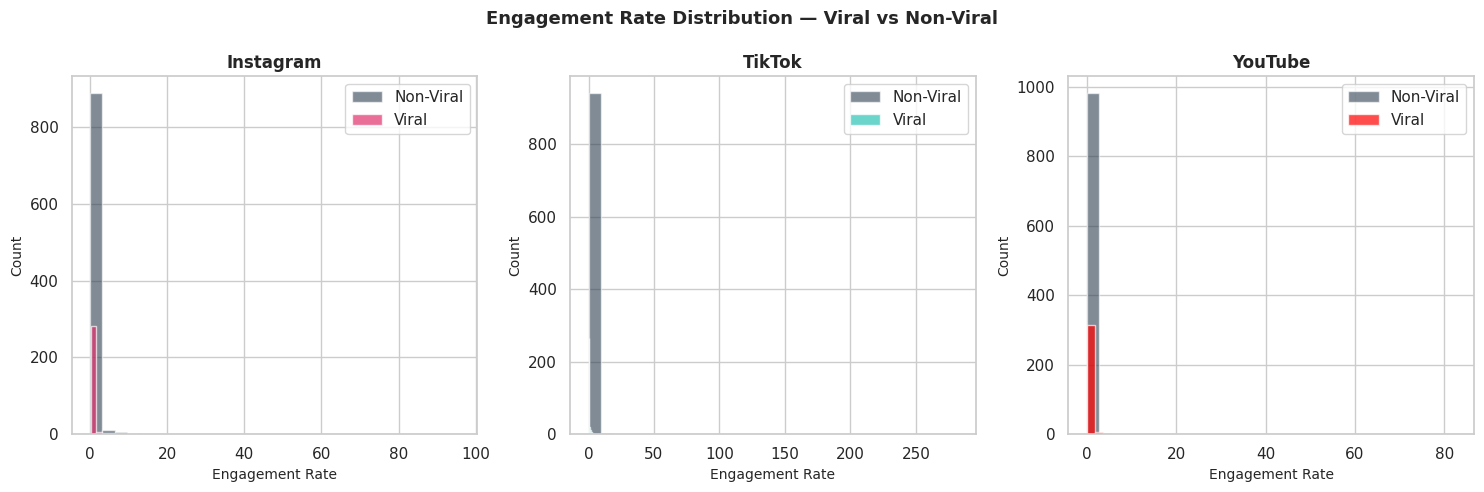

In [8]:
# Engagement rate distribution: Viral vs Non-Viral per platform
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Engagement Rate Distribution — Viral vs Non-Viral", fontsize=13, fontweight='bold')


for ax, p in zip(axes, PLATFORMS):
    temp  = df[df["Platform"] == p]
    non_v = temp[temp["Viral"] == 0]["Engagement_Rate"]
    v     = temp[temp["Viral"] == 1]["Engagement_Rate"]

    ax.hist(non_v, bins=30, alpha=0.6, color='#2C3E50', label="Non-Viral")
    ax.hist(v,     bins=30, alpha=0.7, color=PLATFORM_COLORS[p], label="Viral")

    ax.set_title(p, fontweight='bold')
    ax.set_xlabel("Engagement Rate")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()


#### 6.4 correlation heatmap

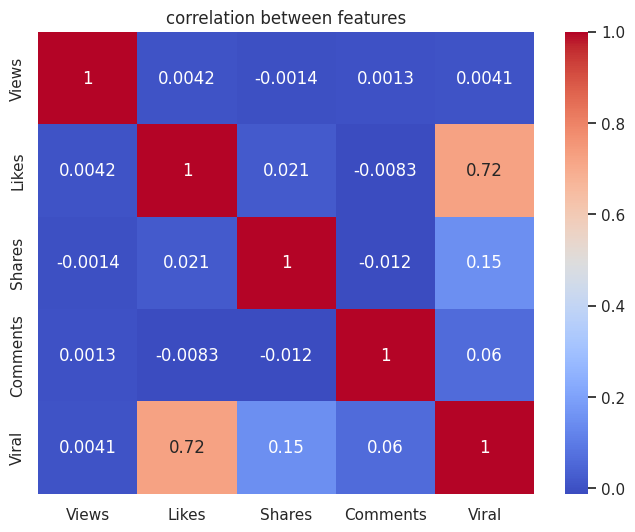

In [9]:
# Note: Engagement_Rate excluded here to stay consistent with feature selection
# (derived features removed to reduce data leakage)
#only use main features instead of derived ones

cols = ["Views", "Likes", "Shares", "Comments", "Viral"]
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("correlation between features")

plt.show()

#### 6.5: Average Engagement Score by Content Type & Platform: Bar Chart

In [ ]:
# Average engagement score by content type and platform

ct_summary = df.groupby(["Content_Type", "Platform"])["Engagement_Score"].mean().reset_index()

plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=ct_summary,
    x="Content_Type", y="Engagement_Score", hue="Platform",
    palette=PLATFORM_COLORS
)
plt.title("Average Engagement Score by Content Type", fontsize=13, fontweight='bold')
plt.xlabel("Content Type")
plt.ylabel("Average Engagement Score")
plt.xticks(rotation=25)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=7, padding=2)

plt.tight_layout()
plt.show()


#### 6.6: Average Engagement by Region

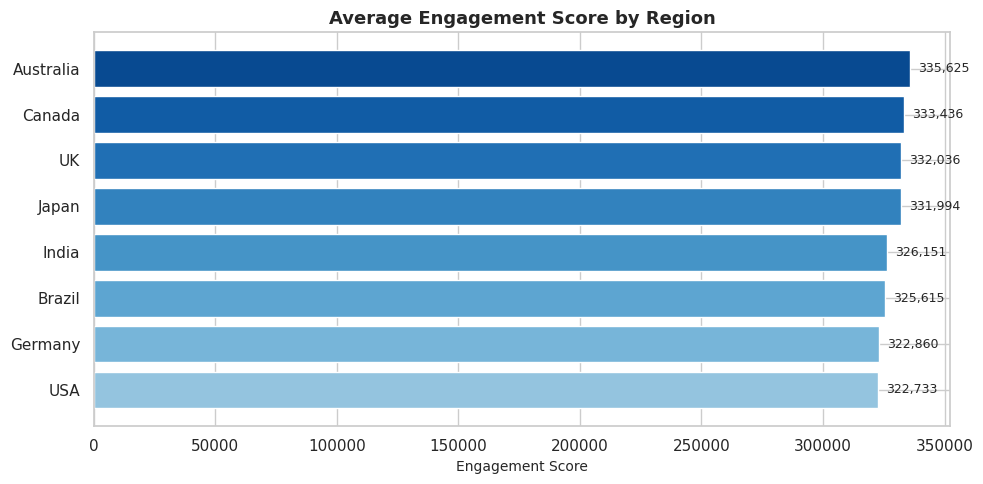

In [11]:
# Average engagement score by region
region_avg = df.groupby("Region")["Engagement_Score"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

cmap   = plt.cm.Blues
colors = [cmap(0.4 + 0.5 * i / max(len(region_avg)-1, 1)) for i in range(len(region_avg))][::-1]

bars = ax.barh(region_avg.index, region_avg.values, color=colors)
ax.set_title("Average Engagement Score by Region", fontsize=13, fontweight='bold')
ax.set_xlabel("Engagement Score")
ax.invert_yaxis()

for i, v in enumerate(region_avg.values):
    ax.text(v + region_avg.max() * 0.01, i, f"{int(v):,}", va='center', fontsize=9)

plt.tight_layout()
plt.show()


#### 6.7: Top 10 Hashtags by Average Engagement Score: Horizontal Bar Chart

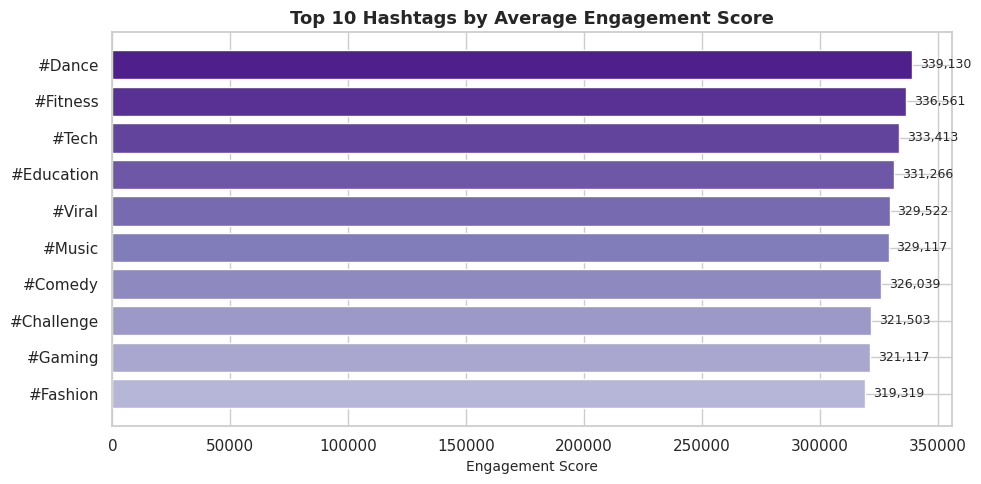

In [12]:
# Top 10 hashtags by average engagement score
top_tags = df.groupby("Hashtag")["Engagement_Score"].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))

cmap   = plt.cm.Purples
colors = [cmap(0.4 + 0.5 * i / 9) for i in range(len(top_tags))][::-1]

ax.barh(top_tags.index, top_tags.values, color=colors)
ax.set_title("Top 10 Hashtags by Average Engagement Score", fontsize=13, fontweight='bold')
ax.set_xlabel("Engagement Score")
ax.invert_yaxis()

for i, v in enumerate(top_tags.values):
    ax.text(v + top_tags.max() * 0.01, i, f"{int(v):,}", va='center', fontsize=9)

plt.tight_layout()
plt.show()


#### 6.8: Engagement Score vs Engagement Rate: Scatter Plot (Viral vs Non-Viral)

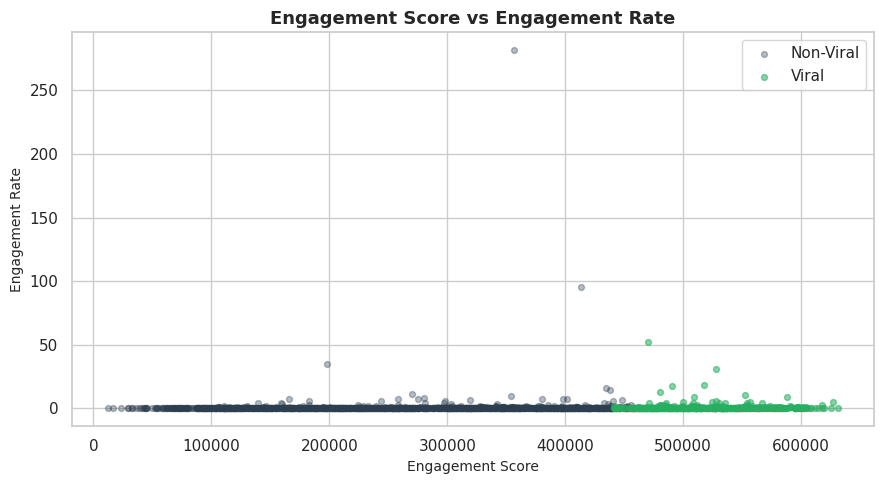

In [13]:
# Engagement Score vs Engagement Rate: Viral vs Non-Viral
sample = df.sample(n=min(2000, len(df)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(9, 5))

non_v = sample[sample["Viral"] == 0]
v     = sample[sample["Viral"] == 1]

ax.scatter(non_v["Engagement_Score"], non_v["Engagement_Rate"],
           alpha=0.35, color='#2C3E50', s=18, label="Non-Viral")
ax.scatter(v["Engagement_Score"], v["Engagement_Rate"],
           alpha=0.55, color='#27AE60', s=18, label="Viral")

ax.set_xlabel("Engagement Score")
ax.set_ylabel("Engagement Rate")
ax.set_title("Engagement Score vs Engagement Rate", fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Platform-Specific Model Training
 
3 model types: 
- **Logistic Regression**: easy to interpret
- **Random Forest**:  handles more complex patterns in the data
- **XGBoost**: gradient boosting for best accuracy

We build separate models per platform because the drivers of virality differ across TikTok, Instagram, and YouTube. A model trained on TikTok data may fail on YouTube because the engagement mechanisms are fundamentally different.

For evaluation we used 
- 70/30 stratified split 
-  5-fold cross-validation.

In [14]:
# features for the  model
# Note:
# Likes, Shares, and Comments are still strongly
# related to virality because the viral label was
# partially derived from engagement metrics.
# However, aggregate and ratio-based features were
# removed to reduce direct data leakage.

# We exclude Engagement_Score, Engagement_Rate, and all ratio features 
# since they are derived from the same raw metrics
# that are used to define the viral label (top 25% Engagement_Score per platform).
# If we were to include them would then there would be  data leakage.

remove_cols = [
    "Viral",
    "Engagement_Score",
    "Engagement_Rate",
    "Like_to_View",
    "Share_to_View",
    "Comment_to_View",
    "Share_to_Like",
    "Platform",
    "Post_ID",
    "Post_Date",
    "Hashtag",
    "Content_Type",
    "Region"
]

num_cols = df.select_dtypes(include=np.number).columns #this keeps only the numeric columns first

#final feature list 
features = []  

for col in num_cols:
    if col not in remove_cols:
        features.append(col)

print("Features Used:", features)

FEATURE_COLS = features


Features Used: ['Views', 'Likes', 'Shares', 'Comments', 'Month', 'DayOfWeek', 'IsWeekend', 'Content_Type_Enc', 'Region_Enc', 'Hashtag_Enc']


In [15]:
# make the models

def build_models():
    models = {}
    # logistic regression (baseline)
    models["Logistic Regression"] = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ])

    #random forest
    models["Random Forest"] = Pipeline([
        ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
    ])
    # xgboost (if it works)
    models["XGBoost"] = Pipeline([
       ("model", xgb.XGBClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            eval_metric="logloss",
            random_state=RANDOM_STATE
        ))
    ])

    return models

#cross validation setup
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Model Blueprints are ready")

Model Blueprints are ready


In [16]:
models = build_models()
print("Models built:", list(models.keys()))

Models built: ['Logistic Regression', 'Random Forest', 'XGBoost']


## 7. Model Evaluation & Comparison

In [17]:

all_results = {}
for platform in PLATFORMS:
    print("\n" + "=" * 45)
    print("platform:", platform)
    print("=" * 45)

    sub = df[df["Platform"] == platform].copy()
    X = sub[FEATURE_COLS].fillna(0)
    y = sub["Viral"]

    print("samples:", len(sub), "| viral:", int(y.sum()), f"({y.mean()*100:.1f}%)")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y
     )
    platform_results = {}
    models = build_models()

    for model_name in models:
        model = models[model_name]
        cv_scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=CV,
            scoring=["roc_auc"]
        )


        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        eval_metrics = {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_prob)
        }
        cv_auc = cv_scores["test_roc_auc"].mean()

        print(
            model_name,
            "| acc:", round(eval_metrics["accuracy"], 3),
            "| f1:", round(eval_metrics["f1"], 3),
            "| auc:", round(eval_metrics["roc_auc"], 3),
            "| cv auc:", round(cv_auc, 3)
        )

        platform_results[model_name] = {
            "pipeline": model,
            "metrics": eval_metrics,
            "cv_auc": cv_auc,
            "y_test": y_test,
            "y_pred": y_pred,
            "y_prob": y_prob
        }
        
    all_results[platform] = platform_results

print("\nall models trained")


platform: Instagram
samples: 1212 | viral: 303 (25.0%)
Logistic Regression | acc: 0.986 | f1: 0.973 | auc: 1.0 | cv auc: 0.999
Random Forest | acc: 0.967 | f1: 0.934 | auc: 0.997 | cv auc: 0.994
XGBoost | acc: 0.989 | f1: 0.978 | auc: 0.999 | cv auc: 0.997

platform: TikTok
samples: 1260 | viral: 315 (25.0%)
Logistic Regression | acc: 0.984 | f1: 0.967 | auc: 0.999 | cv auc: 0.999
Random Forest | acc: 0.963 | f1: 0.925 | auc: 0.996 | cv auc: 0.995
XGBoost | acc: 0.974 | f1: 0.947 | auc: 0.998 | cv auc: 0.998

platform: YouTube
samples: 1324 | viral: 331 (25.0%)
Logistic Regression | acc: 0.982 | f1: 0.964 | auc: 0.999 | cv auc: 0.999
Random Forest | acc: 0.972 | f1: 0.944 | auc: 0.997 | cv auc: 0.997
XGBoost | acc: 0.972 | f1: 0.946 | auc: 0.998 | cv auc: 0.998

all models trained


In [18]:

result_rows = []

for p in all_results:
    
    platform_models = all_results[p]
    
    for name in platform_models:
        res = platform_models[name]
        m = res["metrics"]
        
        result_rows.append({
            "Platform": p,
            "Model": name,
            "Accuracy": round(m["accuracy"], 3),
            "Precision": round(m["precision"], 3),
            "Recall": round(m["recall"], 3),
            "F1": round(m["f1"], 3),
            "AUC": round(m["roc_auc"], 3)
        })

summary_df = pd.DataFrame(result_rows)

summary_df = summary_df.sort_values(["Platform", "AUC"], ascending=[True, False])

print("columns:", summary_df.columns.tolist())
summary_df

# highlight best model per platform
def highlight_best(df):
    style = pd.DataFrame('', index=df.index, columns=df.columns)
    for platform in df['Platform'].unique():
        mask = df['Platform'] == platform
        best_idx = df.loc[mask, 'AUC'].idxmax()
        style.loc[best_idx] = 'background-color: #d4edda; font-weight: bold'
    return style

summary_df.style.apply(highlight_best, axis=None).format({
    'Accuracy': '{:.3f}', 'Precision': '{:.3f}',
    'Recall': '{:.3f}', 'F1': '{:.3f}', 'AUC': '{:.3f}'
})


columns: ['Platform', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC']


,Platform,Model,Accuracy,Precision,Recall,F1,AUC
0,Instagram,Logistic Regression,0.986,0.967,0.978,0.973,1.000
2,Instagram,XGBoost,0.989,0.989,0.967,0.978,0.999
1,Instagram,Random Forest,0.967,0.934,0.934,0.934,0.997
3,TikTok,Logistic Regression,0.984,0.989,0.947,0.967,0.999
5,TikTok,XGBoost,0.974,0.947,0.947,0.947,0.998
4,TikTok,Random Forest,0.963,0.935,0.915,0.925,0.996
6,YouTube,Logistic Regression,0.982,0.969,0.960,0.964,0.999
8,YouTube,XGBoost,0.972,0.915,0.980,0.946,0.998
7,YouTube,Random Forest,0.972,0.949,0.939,0.944,0.997


In [ ]:
# Confusion matrices — Logistic Regression (counts + row %)
# (Logistic Regression selected as it achieved the best overall ROC-AUC)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Confusion Matrices — Logistic Regression", fontsize=13, fontweight='bold')

for i, p in enumerate(PLATFORMS):
    ax  = axes[i]
    res = all_results[p]["Logistic Regression"]
    cm  = confusion_matrix(res["y_test"], res["y_pred"])

    # build annotation with count and row %
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_pct   = cm / row_sums * 100
    annot    = np.array([[f"{cm[r,c]}\n({cm_pct[r,c]:.1f}%)"
                          for c in range(2)] for r in range(2)])

    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", ax=ax,
                linewidths=0.5, linecolor="white",
                xticklabels=["Non-Viral","Viral"],
                yticklabels=["Non-Viral","Viral"])
    ax.set_title(p, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


In [20]:
#Detailed classification report per platform (XGBoost)
for platform in PLATFORMS:
    res = all_results[platform]['XGBoost']
    print(f'\n--- {platform} — XGBoost ---')
    print(classification_report(res['y_test'], res['y_pred'],
                                target_names=['Non-Viral', 'Viral']))


--- Instagram — XGBoost ---
              precision    recall  f1-score   support

   Non-Viral       0.99      1.00      0.99       273
       Viral       0.99      0.97      0.98        91

    accuracy                           0.99       364
   macro avg       0.99      0.98      0.99       364
weighted avg       0.99      0.99      0.99       364


--- TikTok — XGBoost ---
              precision    recall  f1-score   support

   Non-Viral       0.98      0.98      0.98       284
       Viral       0.95      0.95      0.95        94

    accuracy                           0.97       378
   macro avg       0.96      0.96      0.96       378
weighted avg       0.97      0.97      0.97       378


--- YouTube — XGBoost ---
              precision    recall  f1-score   support

   Non-Viral       0.99      0.97      0.98       299
       Viral       0.92      0.98      0.95        99

    accuracy                           0.97       398
   macro avg       0.95      0.97      0.96   

## 8. Feature Importance & ROC Curves

In [ ]:
# Top feature importances — Random Forest per platform

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Top Feature Importances — Random Forest", fontsize=13, fontweight='bold')

for i, p in enumerate(PLATFORMS):
    ax   = axes[i]
    pipe = all_results[p]["Random Forest"]["pipeline"]
    imp_df = pd.Series(pipe.named_steps["model"].feature_importances_, index=FEATURE_COLS)
    imp_df = imp_df.sort_values(ascending=False).head(8)

    color = PLATFORM_COLORS[p]
    bars  = ax.barh(imp_df.index[::-1], imp_df.values[::-1], color=color, alpha=0.85)

    # percent labels
    total = imp_df.values.sum()
    for bar, val in zip(bars, imp_df.values[::-1]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val/total*100:.1f}%", va='center', fontsize=8)

    ax.set_title(p, fontweight='bold')
    ax.set_xlabel("Importance")
    ax.set_xlim(0, imp_df.values.max() * 1.25)

plt.tight_layout()
plt.show()


In [ ]:
# ROC curves — all models per platform
MODEL_COLORS = {
    'Logistic Regression': '#3498DB',
    'Random Forest':       '#27AE60',
    'XGBoost':             '#E74C3C',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("ROC Curves by Platform", fontsize=13, fontweight='bold')

for i, platform in enumerate(PLATFORMS):
    ax = axes[i]
    for model_name in all_results[platform]:
        res = all_results[platform][model_name]
        fpr, tpr, _ = roc_curve(res["y_test"], res["y_prob"])
        auc = res["metrics"]["roc_auc"]
        ax.plot(fpr, tpr,
                color=MODEL_COLORS[model_name], linewidth=2,
                label=f"{model_name}  (AUC={auc:.2f})")

    ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random")
    ax.set_title(platform, fontweight='bold')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 9. Interactive Viral Predictor

Enter a post's details to predict whether it will go viral using the best-performing model per platform.

In [23]:
# these are maps for the predictor 
content_map   = {v: i for i, v in enumerate(sorted(df['Content_Type'].unique()))}
region_map    = {v: i for i, v in enumerate(sorted(df['Region'].unique()))}
hashtag_map   = {v: i for i, v in enumerate(sorted(df['Hashtag'].unique()))}

# Finding the best model per platform by ROC-AUC
# The strong performance of Logistic Regression suggests that engagement metrics
# had relatively linear and separable relationships with virality within this dataset.
best_models = {}
for platform in PLATFORMS:
    best_name = max(all_results[platform],
                    key=lambda m: all_results[platform][m]['metrics']['roc_auc'])
    best_models[platform] = (best_name, all_results[platform][best_name]['pipeline'])
    print(f'  {platform:12s} → Best Model: {best_name}  (AUC: {all_results[platform][best_name]["metrics"]["roc_auc"]:.3f})')

print()
print('Available content types:', list(content_map.keys()))
print('Available regions   :', list(region_map.keys()))
print('Available hashtags  :', list(hashtag_map.keys()))

  Instagram    → Best Model: Logistic Regression  (AUC: 1.000)
  TikTok       → Best Model: Logistic Regression  (AUC: 0.999)
  YouTube      → Best Model: Logistic Regression  (AUC: 0.999)

Available content types: ['Live Stream', 'Post', 'Reel', 'Shorts', 'Tweet', 'Video']
Available regions   : ['Australia', 'Brazil', 'Canada', 'Germany', 'India', 'Japan', 'UK', 'USA']
Available hashtags  : ['#Challenge', '#Comedy', '#Dance', '#Education', '#Fashion', '#Fitness', '#Gaming', '#Music', '#Tech', '#Viral']



--- Example 1: High-engagement TikTok video ---
  POST VIRAL PREDICTION  [Logistic Regression]
  Platform      : TikTok
  Content Type  : Video
  Region        : USA
  Hashtag       : #Challenge
  Views         :    4,500,000
  Likes         :      450,000
  Shares        :       85,000
  Comments      :       40,000
-------------------------------------------------------
  Engagement Score       : 575,000
  Platform Viral Threshold: 440,542
  Viral Probability : 99.8%
  Prediction        : >>> VIRAL 🚀 <<<


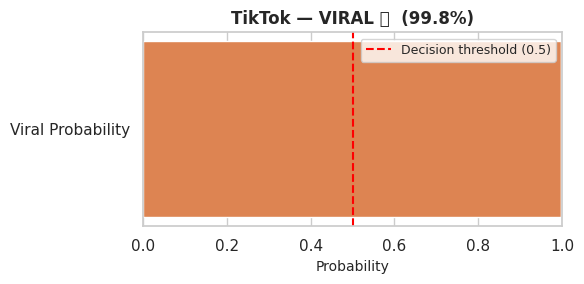


--- Example 2: Low-engagement Instagram post ---
  POST VIRAL PREDICTION  [Logistic Regression]
  Platform      : Instagram
  Content Type  : Post
  Region        : India
  Hashtag       : #Education
  Views         :       10,000
  Likes         :          500
  Shares        :           50
  Comments      :           30
-------------------------------------------------------
  Engagement Score       : 580
  Platform Viral Threshold: 461,652
  Viral Probability : 0.0%
  Prediction        : >>> Not Viral <<<


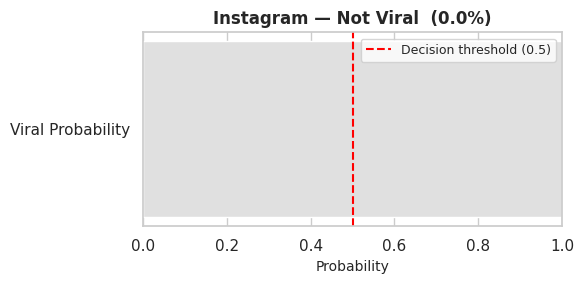

{'label': 'Not Viral', 'probability': np.float64(0.0), 'engagement_score': 580}

In [24]:
def predict_viral(
    views: int,
    likes: int,
    shares: int,
    comments: int,
    platform: str      = 'TikTok',
    content_type: str  = 'Video',
    region: str        = 'USA',
    hashtag: str       = '#Challenge',
    month: int         = 6,
    day_of_week: int   = 2
):
    """
    Predict whether a social media post will go viral.
    Uses the best-performing model for the specified platform.
    """
    if platform not in PLATFORMS:
        print(f'Platform must be one of {PLATFORMS}')
        return None

    best_name, best_pipe = best_models[platform]

    safe_views       = views if views > 0 else 1
    engagement_score = likes + comments + shares
    is_weekend       = int(day_of_week >= 5)

    if content_type not in content_map:
        print(f'Warning: unknown content_type "{content_type}", defaulting to index 0')
    if region not in region_map:
        print(f'Warning: unknown region "{region}", defaulting to index 0')
    if hashtag not in hashtag_map:
        print(f'Warning: unknown hashtag "{hashtag}", defaulting to index 0')
    content_enc  = content_map.get(content_type, 0)
    region_enc   = region_map.get(region, 0)
    hashtag_enc  = hashtag_map.get(hashtag, 0)

    # Must match FEATURE_COLS order exactly
    row = pd.DataFrame([{
        'Views': safe_views, 'Likes': likes, 'Shares': shares, 'Comments': comments,
        'Content_Type_Enc': content_enc,
        'Region_Enc': region_enc,
        'Hashtag_Enc': hashtag_enc,
        'Month': month,
        'DayOfWeek': day_of_week,
        'IsWeekend': is_weekend
    }])[FEATURE_COLS]

    prob  = best_pipe.predict_proba(row)[0][1]
    label = 'VIRAL 🚀' if prob >= 0.5 else 'Not Viral'

    # Get platform-specific viral threshold
    platform_threshold = df[df['Platform']==platform]['Engagement_Score'].quantile(VIRAL_PERCENTILE/100)

    print('=' * 55)
    print(f'  POST VIRAL PREDICTION  [{best_name}]')
    print('=' * 55)
    print(f'  Platform      : {platform}')
    print(f'  Content Type  : {content_type}')
    print(f'  Region        : {region}')
    print(f'  Hashtag       : {hashtag}')
    print(f'  Views         : {views:>12,}')
    print(f'  Likes         : {likes:>12,}')
    print(f'  Shares        : {shares:>12,}')
    print(f'  Comments      : {comments:>12,}')
    print('-' * 55)
    print(f'  Engagement Score       : {engagement_score:,}')
    print(f'  Platform Viral Threshold: {platform_threshold:,.0f}')
    print('=' * 55)
    print(f'  Viral Probability : {prob*100:.1f}%')
    print(f'  Prediction        : >>> {label} <<<')
    print('=' * 55)

    # Probability bar chart
    fig, ax = plt.subplots(figsize=(6, 3))
    bar_color = '#DD8452' if prob >= 0.5 else '#4C72B0'
    ax.barh(['Viral Probability'], [prob], color=bar_color, height=0.4)
    ax.barh(['Viral Probability'], [1 - prob], left=[prob],
            color='#e0e0e0', height=0.4)
    ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Probability')
    ax.set_title(f'{platform} — {label}  ({prob*100:.1f}%)', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    return {'label': label, 'probability': round(prob, 4),
            'engagement_score': engagement_score}


# --- Example predictions ---
print('\n--- Example 1: High-engagement TikTok video ---')
predict_viral(views=4_500_000, likes=450_000, shares=85_000, comments=40_000,
              platform='TikTok', content_type='Video', region='USA',
              hashtag='#Challenge', month=7, day_of_week=6)

print('\n--- Example 2: Low-engagement Instagram post ---')
predict_viral(views=10_000, likes=500, shares=50, comments=30,
              platform='Instagram', content_type='Post', region='India',
              hashtag='#Education', month=3, day_of_week=1)

## Summary

| Section | Key Finding |
|---------|-------------|
| **Data** | 5,000 posts across TikTok, Instagram, YouTube (2022–2023) |
| **Viral Label** | Top 25% Engagement Score **per platform** — avoids global threshold bias |
| **Features** | Raw metrics + temporal (Month, DayOfWeek, IsWeekend) + categorical (Content, Region, Hashtag) |
| **Leakage Issue** | Ratio features (Engagement_Rate, Like_to_View etc.) excluded — derived from same metrics as label |
| **AUC Limitation** | Near-perfect AUC due to synthetic dataset — no natural noise in engagement numbers |
| **Best Models** | Logistic Regression achieved the strongest overall ROC-AUC performance across all platforms |
| **Key Insight** | Platform-specific models outperform a single global model — virality drivers differ per platform |
| **Why LR Won** | The strong performance of Logistic Regression suggests that engagement metrics had relatively linear and separable relationships with virality within this dataset. |
